In [1]:
from helpers import *
import cv2
import numpy as np
from ipywidgets import interact, FloatSlider, IntSlider
%matplotlib widget
print("✅ Environment Ready!")

✅ Environment Ready!


Image loaded! Shape: (1280, 1280, 3), dtype: uint8


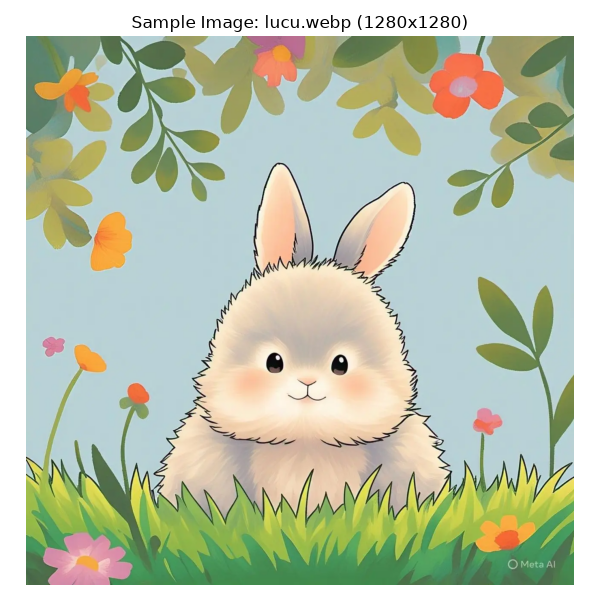

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load sample image
img = cv2.imread('/home/lann/Project/PCD/lucu.webp')

if img is None:
    # Fallback: convert via PIL jika cv2 tidak support webp
    try:
        from PIL import Image as PILImage
        pil_img = PILImage.open('/home/lann/Project/PCD/lucu256.webp').convert('RGB')
        img = np.array(pil_img)[:, :, ::-1]  # RGB to BGR
    except Exception as e:
        # Fallback kedua ke lucu256.png
        img = cv2.imread('/home/lann/Project/PCD/lucu256.png')
        if img is None:
            raise FileNotFoundError(f"Tidak bisa load gambar: {e}")

# Convert BGR to RGB untuk display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(f"Image loaded! Shape: {img.shape}, dtype: {img.dtype}")

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"Sample Image: lucu.webp ({img.shape[1]}x{img.shape[0]})")
plt.axis('off')
plt.tight_layout()
plt.show()

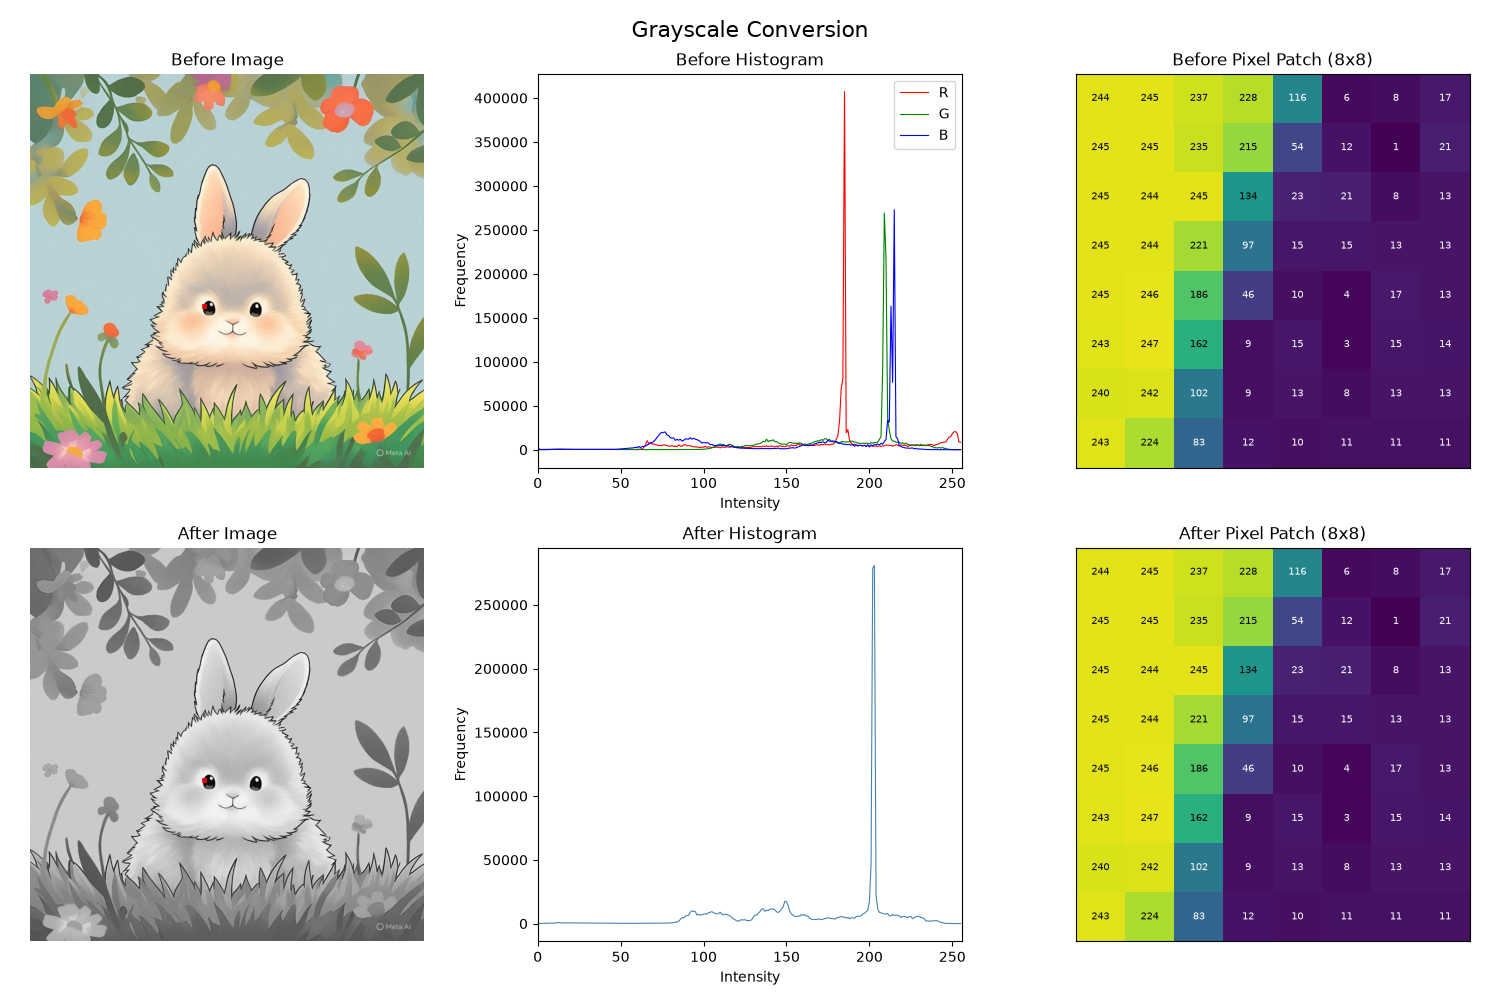

In [3]:
gray_result = grayscale(img_rgb)
show_result(img_rgb, gray_result, "Grayscale Conversion")

In [4]:
@interact(delta=(-100, 100, 5))
def adjust_brightness(delta=50):
    bright = brightness(img_rgb, delta)
    show_result(img_rgb, bright, f"Brightness (delta={delta})")

interactive(children=(IntSlider(value=50, description='delta', min=-100, step=5), Output()), _dom_classes=('wi…

In [5]:
@interact(value=(0, 255, 5))
def apply_threshold(value=128):
    thresh = threshold(grayscale(img_rgb), value)
    show_result(img_rgb, thresh, f"Threshold (value={value})")

interactive(children=(IntSlider(value=128, description='value', max=255, step=5), Output()), _dom_classes=('wi…

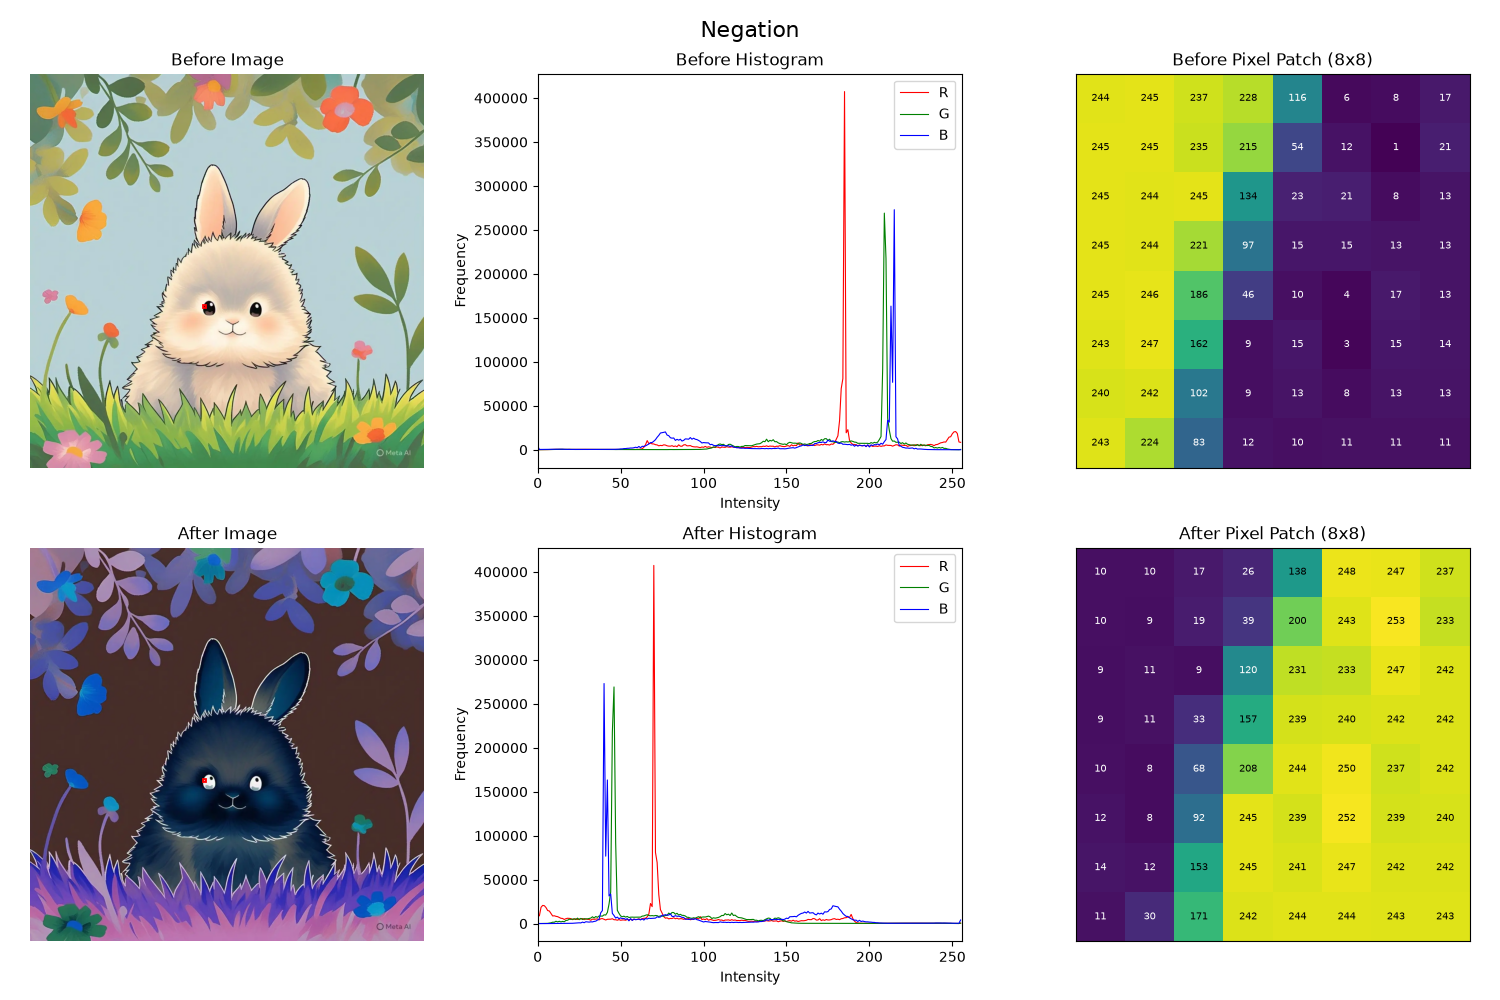

In [6]:
neg_result = negation(img_rgb)
show_result(img_rgb, neg_result, "Negation")

In [7]:
@interact(gamma=(0.2, 3.0, 0.1))
def adjust_gamma(gamma=1.0):
    gamma_img = gamma_correction(img_rgb, gamma)
    show_result(img_rgb, gamma_img, f"Gamma Correction (gamma={gamma:.1f})")

interactive(children=(FloatSlider(value=1.0, description='gamma', max=3.0, min=0.2), Output()), _dom_classes=(…

In [8]:
@interact(auto=[True, False])
def adjust_contrast(auto=True):
    contrast_img = contrast_stretching(img_rgb, auto=auto)
    show_result(img_rgb, contrast_img, f"Contrast Stretching (auto={auto})")

interactive(children=(Dropdown(description='auto', options=(True, False), value=True), Output()), _dom_classes…

In [9]:
@interact(lower=(0, 255, 10), upper=(0, 255, 10))
def slice_intensity(lower=80, upper=180):
    if lower > upper:
        lower, upper = upper, lower
    sliced = intensity_slicing(img_rgb, lower, upper)
    show_result(img_rgb, sliced, f"Intensity Slicing [{lower}-{upper}]")

interactive(children=(IntSlider(value=80, description='lower', max=255, step=10), IntSlider(value=180, descrip…

In [10]:
@interact(bit=(0, 7, 1))
def do_extract_bit(bit=7):
    bit_img = bit_extraction(img_rgb, bit)
    show_result(img_rgb, bit_img, f"Bit Extraction (Bit {bit})")

interactive(children=(IntSlider(value=7, description='bit', max=7), Output()), _dom_classes=('widget-interact'…

In [11]:
@interact(c=(1, 20, 1))
def compress_range(c=10):
    compressed = range_compression(img_rgb, c)
    show_result(img_rgb, compressed, f"Range Compression (c={c})")

interactive(children=(IntSlider(value=10, description='c', max=20, min=1), Output()), _dom_classes=('widget-in…

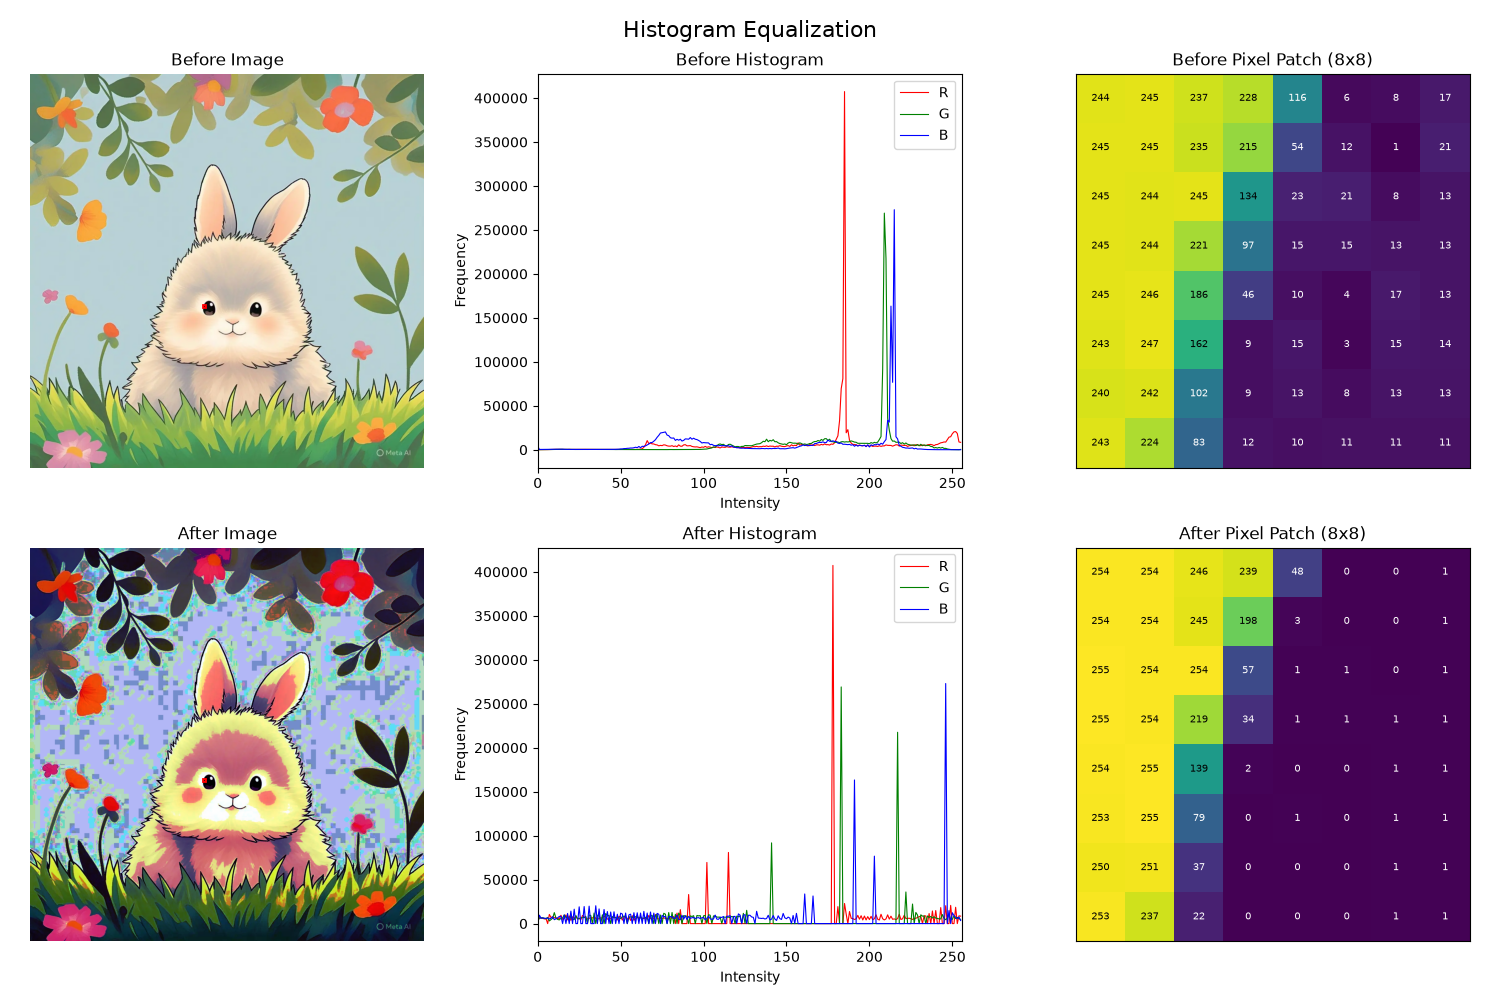

In [12]:
equalized = histogram_equalization(img_rgb)
show_result(img_rgb, equalized, "Histogram Equalization")

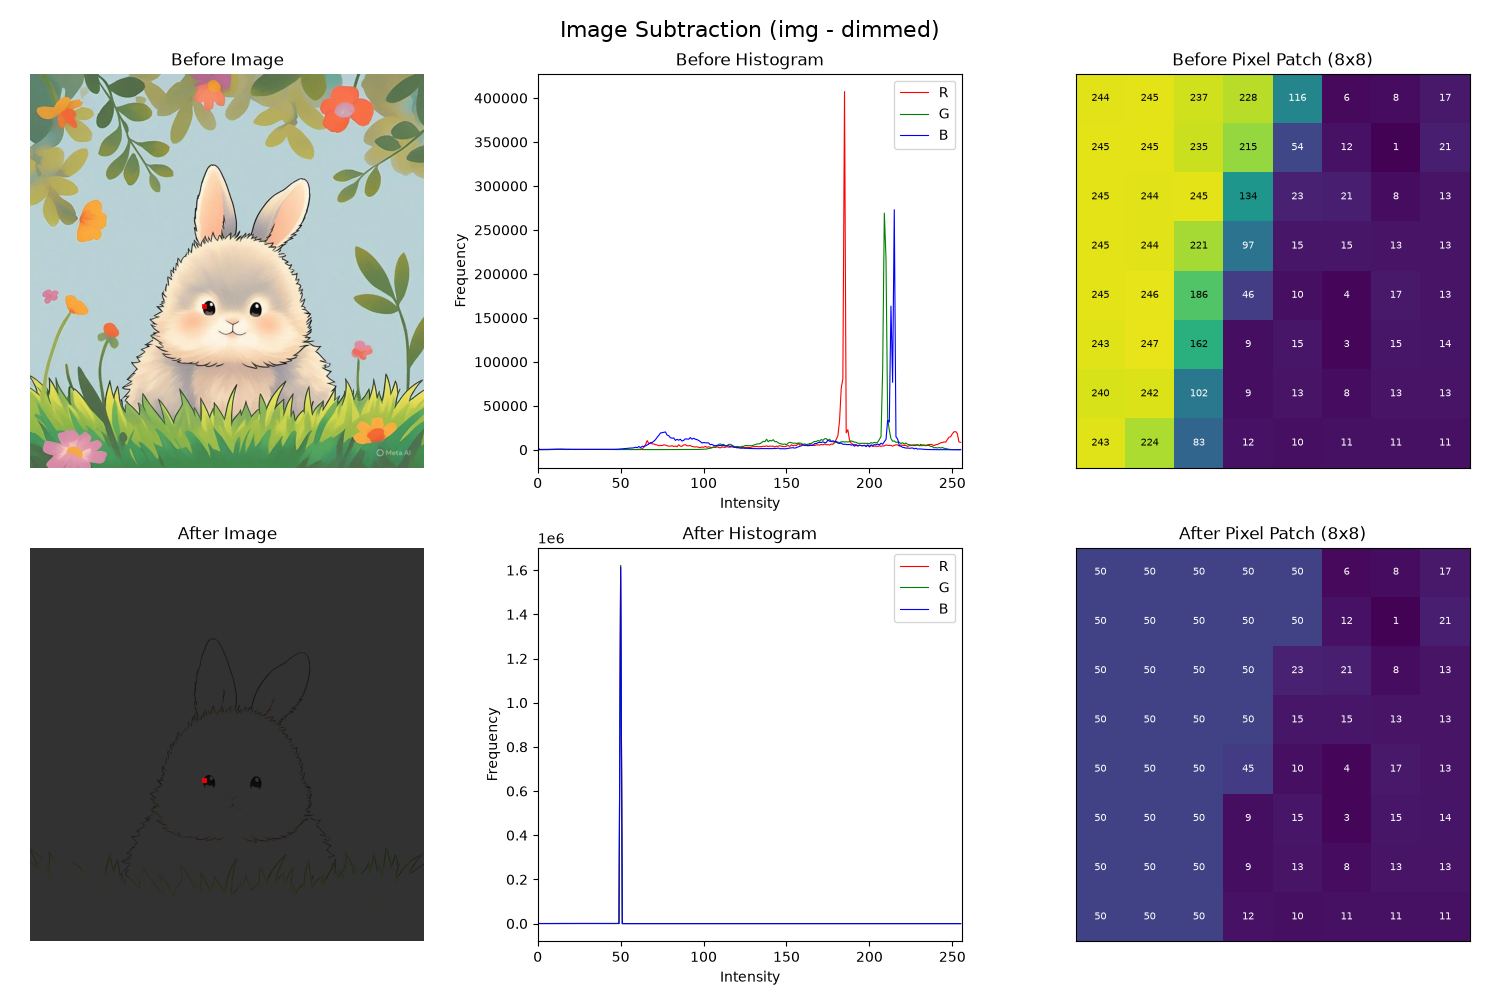

In [13]:
img1 = img_rgb.copy()
img2 = brightness(img_rgb, -50)
result_sub = image_subtraction(img1, img2)
show_result(img_rgb, result_sub, "Image Subtraction (img - dimmed)")

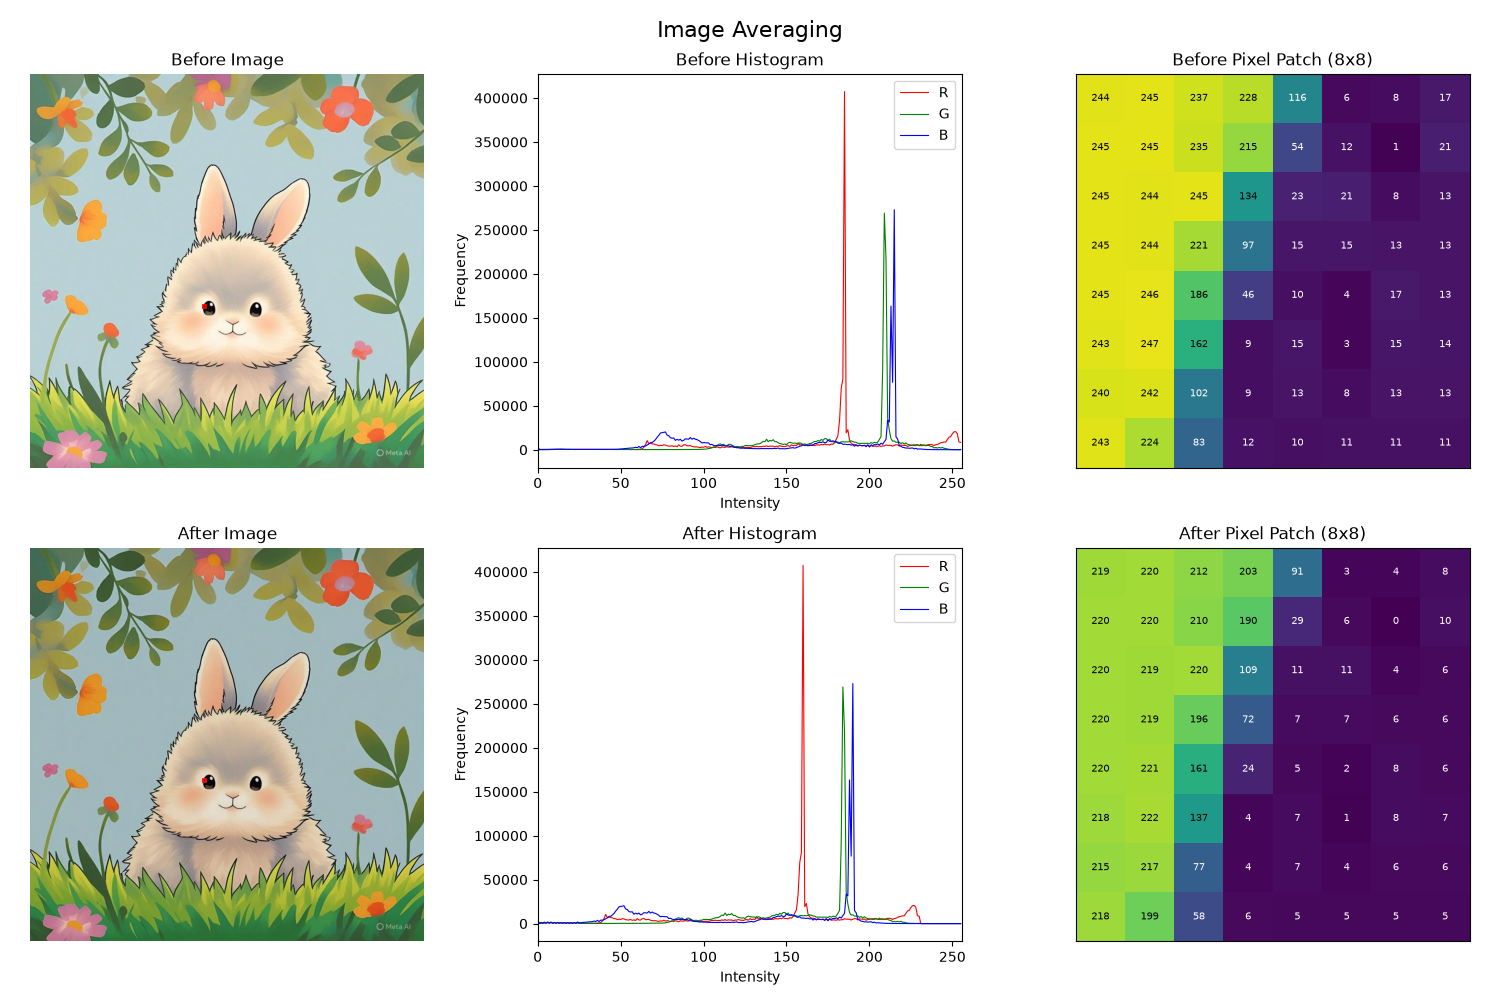

In [14]:
img1 = img_rgb.copy()
img2 = brightness(img_rgb, -50)
result_avg = image_averaging(img1, img2)
show_result(img1, result_avg, "Image Averaging")
